# Capstone Black Box Project

## Function 3 - Drug Harmful Effects

Drug discovery project, testing combinations of three compounds to create a new medicine. Goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

## Submission 10 of 13

In [15]:
# Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress

## 1. Load Data

In [16]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_3"

def load_npy_files(function_name):
    initial_inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    initial_outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return initial_inputs, initial_outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 24
[[0.34194  0.383375 0.436052]
 [0.366844 0.433619 0.499863]]
[-0.00636326 -0.00945663]


## 2. Describe and Review Data

In [17]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


               0          1          2
count  24.000000  24.000000  24.000000
mean    0.384063   0.470706   0.426061
std     0.241098   0.239544   0.255205
min     0.046809   0.126286   0.007434
25%     0.204392   0.308737   0.248127
50%     0.313610   0.396696   0.447129
75%     0.551204   0.651052   0.501556
max     0.965995   0.984764   0.990882
               0
count  24.000000
mean   -0.080474
std     0.080416
min    -0.398926
25%    -0.111592
50%    -0.067575
75%    -0.032550
max    -0.006363


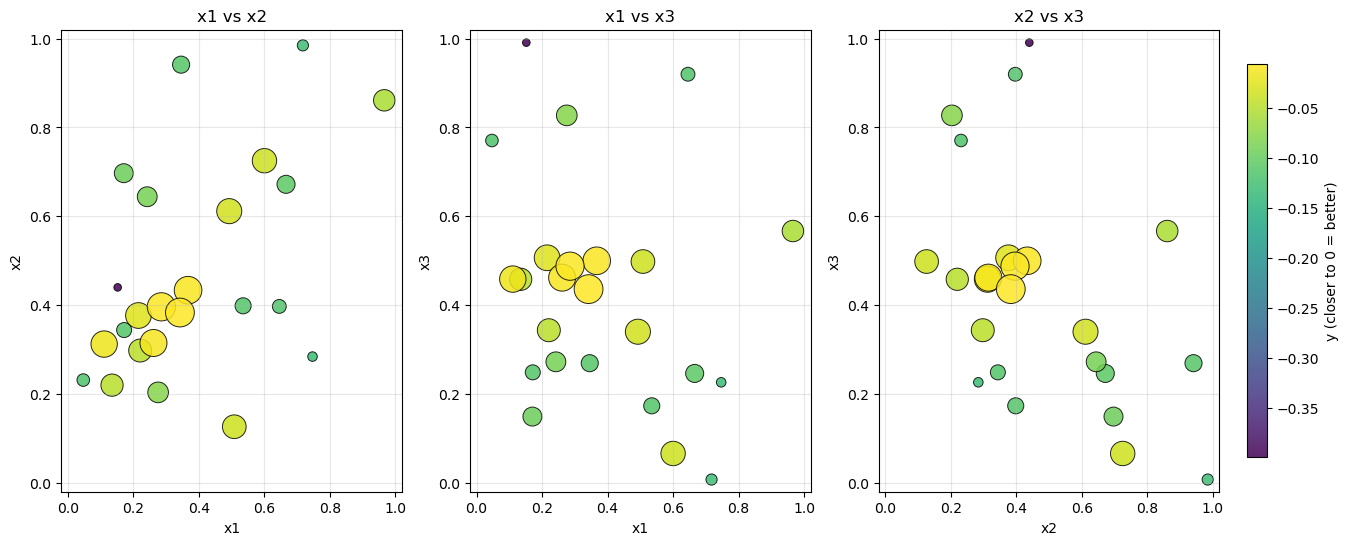

In [18]:
from scipy.stats import rankdata

# Rank-based sizing: robust to the P7 outlier squashing the scale.
# rank 1 = worst, rank n = best -> evenly spread sizes regardless of magnitude gaps.
ranks = rankdata(y)
sizes = 30 + 400 * (ranks - 1) / (len(y) - 1)
order = np.argsort(sizes)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (1, 2, 'x2', 'x3')]

for ax, (i, j, xi, xj) in zip(axes, pairs):
    sc = ax.scatter(X[order, i], X[order, j], c=y[order], cmap='viridis',
                     s=sizes[order], edgecolors='k', linewidths=0.7, alpha=0.85)
    ax.set_xlabel(xi); ax.set_ylabel(xj)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_title(f'{xi} vs {xj}')
    ax.grid(alpha=0.3)

fig.colorbar(sc, ax=axes, location='right', shrink=0.85, pad=0.02, label='y (closer to 0 = better)')
plt.show()

## 3. Transform Data

In [19]:
# No transforms applied

y_fit = y

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./Data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_3 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

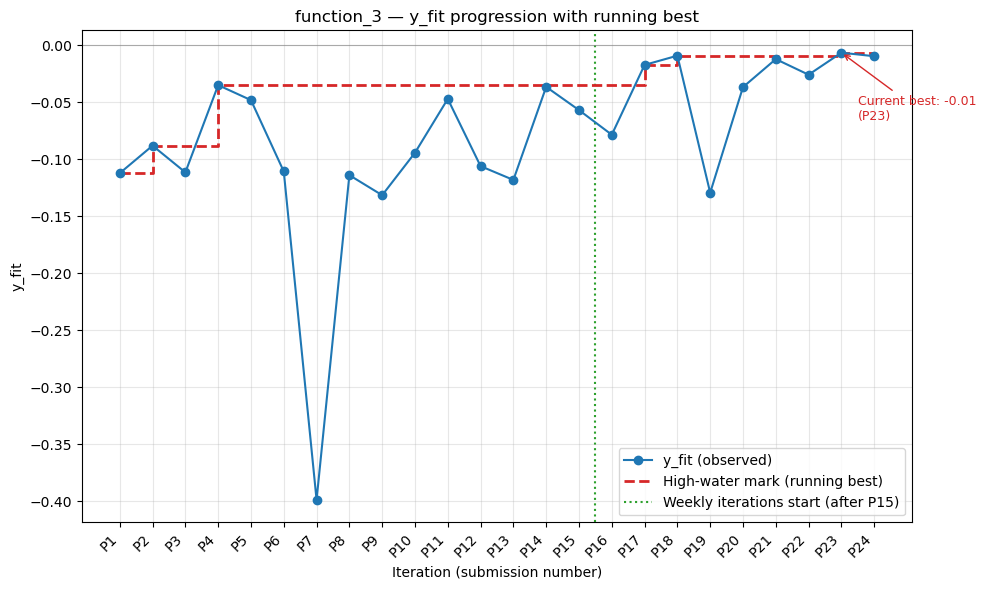

In [20]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=15, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernel

In [21]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)), # wk6
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    # --- Week 7: noisy variants: same structure + fitted observation noise ---
    'RBF4':   ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    print(f"{name:12s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}")
    

Matern_2.5    LML=-25.7061  AIC=55.4122  BIC=57.7683  kernel=1.3**2 * Matern(length_scale=0.309, nu=2.5)
Matern_1.5    LML=-26.2811  AIC=56.5621  BIC=58.9182  kernel=1.47**2 * Matern(length_scale=0.429, nu=1.5)
Matern_0.5    LML=-29.5944  AIC=63.1887  BIC=65.5448  kernel=1.34**2 * Matern(length_scale=0.672, nu=0.5)
RBF1          LML=-25.7279  AIC=55.4559  BIC=57.8120  kernel=1.13**2 * RBF(length_scale=0.199)
RBF2          LML=-27.0352  AIC=58.0704  BIC=60.4265  kernel=1.51**2 * RBF(length_scale=0.25)
RBF3          LML=-25.7279  AIC=55.4559  BIC=57.8120  kernel=1.13**2 * RBF(length_scale=0.199)
RBF4          LML=-25.2756  AIC=56.5512  BIC=60.0853  kernel=1.2**2 * RBF(length_scale=0.228) + WhiteKernel(noise_level=0.00474)


In [22]:
# Fit Gaussian Process
# Select the best kernel for fitting

kernel = kernels['RBF1']

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

1.13**2 * RBF(length_scale=0.199)
LML:       -25.7279


In [23]:
# Prediction Grid - Generate candidates and predict y
# Candidates are used by the EI acquisition function cell below

n_candidates = 10000
low = np.zeros(X.shape[1])
high = np.ones(X.shape[1])

if function == "function_3":
    high[2] = 0.55   # x3 ceiling per danger-zone policy

rng = np.random.default_rng(42)
grid = rng.uniform(
low=low,
high=high,
size=(n_candidates, X.shape[1]))

print("Shape:", grid.shape)
print("Dimensions:", grid.ndim)
print("\nFirst 5 rows:")
print(grid[:5])
    
# GP predictions
mu, sigma = gpr.predict(grid, return_std=True)


Shape: (10000, 3)
Dimensions: 2

First 5 rows:
[[0.77395605 0.43887844 0.47222886]
 [0.69736803 0.09417735 0.53659229]
 [0.7611397  0.78606431 0.0704625 ]
 [0.45038594 0.37079802 0.50972074]
 [0.64386512 0.82276161 0.24387781]]


## 5. Define Acquisition Function

In [24]:
 
xi_values = {
    "function_3": 0.01, #wk6
    #"function_3": 0.01,#wk3 
    #"function_3": 0.1 #wk4
}

In [25]:
# Expected Improvement acquisition function
# EI cross-check (diagnostic only — see LHS cell for actual candidate)

y_best = np.max(y_fit)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.01 for function_3
Next Idx:  7402
Current best y: -0.006363262195730081
Next point to evaluate: [0.41248478 0.69582556 0.01667253]
Formatted next point to evaluate: 0.412485-0.695826-0.016673
Expected improvement: 0.011640361226835011
Predicted mean: -0.026123254079754223
Predicted std: 0.05914337143870674
Improvement: -0.029759991884024145


## LHS Local Search — Method Summary

**Latin Hypercube Sampling (LHS)** is a stratified sampling method: it divides each input dimension into `n` equal-probability intervals and draws exactly one sample per interval per dimension, then randomly pairs those interval samples across dimensions. This guarantees even coverage across each dimension individually — unlike plain uniform random sampling, which can leave gaps or cluster points by chance, especially with a small candidate count.

**How it's used here (TuRBO-style local search):**

1. **Centre** the search on the current incumbent (`x_best`, the best point observed so far).
2. **Bound** the search to a hypercube of radius `r` around that centre (clipped to stay within the domain, and to any hard constraints — e.g. Function 3's x3 ≤ 0.55 danger-zone ceiling).
3. **Sample** candidate points via LHS within those bounds.
4. **Score** each candidate using the GP's predicted mean (`gpr.predict`), filtering out any candidate too close to an already-evaluated point (duplicate/near-duplicate exclusion radius).
5. **Select** the candidate with the highest predicted mean as the next query.

This is a local, exploitation-focused search — it trusts the GP's model of the surface *near the current best point* rather than searching the full domain, on the logic that once a promising region has been found, it's more efficient to refine within it than to keep exploring broadly.

---

### Definition of `r` — the trust-region radius

`r` defines the size of the local hypercube searched around the current incumbent, in each input dimension. It controls the exploitation/exploration trade-off of the local search:

- **Small `r`** → tight, conservative search close to the known best point. Good when the surface nearby is well-understood and you want to refine carefully, but risks missing improvements just outside the searched region.
- **Large `r`** → broader local search, more willing to step away from the current best. Good for testing whether the surrounding region continues to improve, but risks proposing candidates in territory the GP has little real evidence about.

**`r` is adapted dynamically (TuRBO-style trust-region discipline), not fixed:**
- **Expand** `r` after a successful step (the new candidate improved on the incumbent) — the model's local read is working, so it's worth searching a wider area next time.
- **Shrink** `r` after a failed step (the new candidate did not improve) — the model's local read may be overreaching, so the next search is pulled in tighter.
- A cap is kept on both ends (e.g. `r` capped around ~0.2 on expansion, and not shrunk below a minimum useful search size) to avoid the trust region growing unbounded or collapsing to a single point.

This adaptive shrink/expand behaviour is what distinguishes it from a fixed-radius local search — the radius itself is treated as a signal of how much the model's local prediction is currently being trusted, based on whether recent steps have actually paid off.

In [26]:
# LHS Hyprercube alternative method

# This a single, isotropic, argmax-driven trust-region search inspired by TuRBO's expand/shrink discipline,
# simplified for a low-dimensional, tightly-budgeted setting rather than implying full TuRBO

x_best = X[np.argmax(y)]
#r = 0.12 wk7
#r = 0.06 #wk8
#r = 0.12 #wk9
r = 0.06  # wk10 — shrunk after P24 failure at r=0.12

bounds_low  = np.array([max(0.05, x_best[i] - r) for i in range(3)])
bounds_high = np.array([min(0.55 if i == 2 else 0.95, x_best[i] + r) for i in range(3)])

sampler = LatinHypercube(d=3, seed=42)
# lhs = sampler.random(n=20) wk7
lhs = sampler.random(n=60) #wk8
candidates = bounds_low + lhs * (bounds_high - bounds_low)

# Pick candidate with highest GP mean
mu_c, _ = gpr.predict(candidates, return_std=True)

dmin = cdist(candidates, X).min(axis=1)   # distance from each candidate to nearest evaluated point - wk7 enhancement to avoid duplicate candidates
valid = dmin > 0.05                        # exclusion radius

best_idx = np.argmax(mu_c[valid])
next_x = candidates[valid][best_idx]

print("r radius:", r)
print("Next point:", next_x)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu filtered:", mu_c[valid][best_idx])
print("mu unflitered:", mu_c[np.argmax(mu_c)])   

r radius: 0.06
Next point: [0.32148552 0.43226583 0.44992437]
Formatted: 0.321486-0.432266-0.449924
mu filtered: -0.004609059535809895
mu unflitered: -0.004196112479756667


## 6. Plots for Uncertainty and Signal Strength 

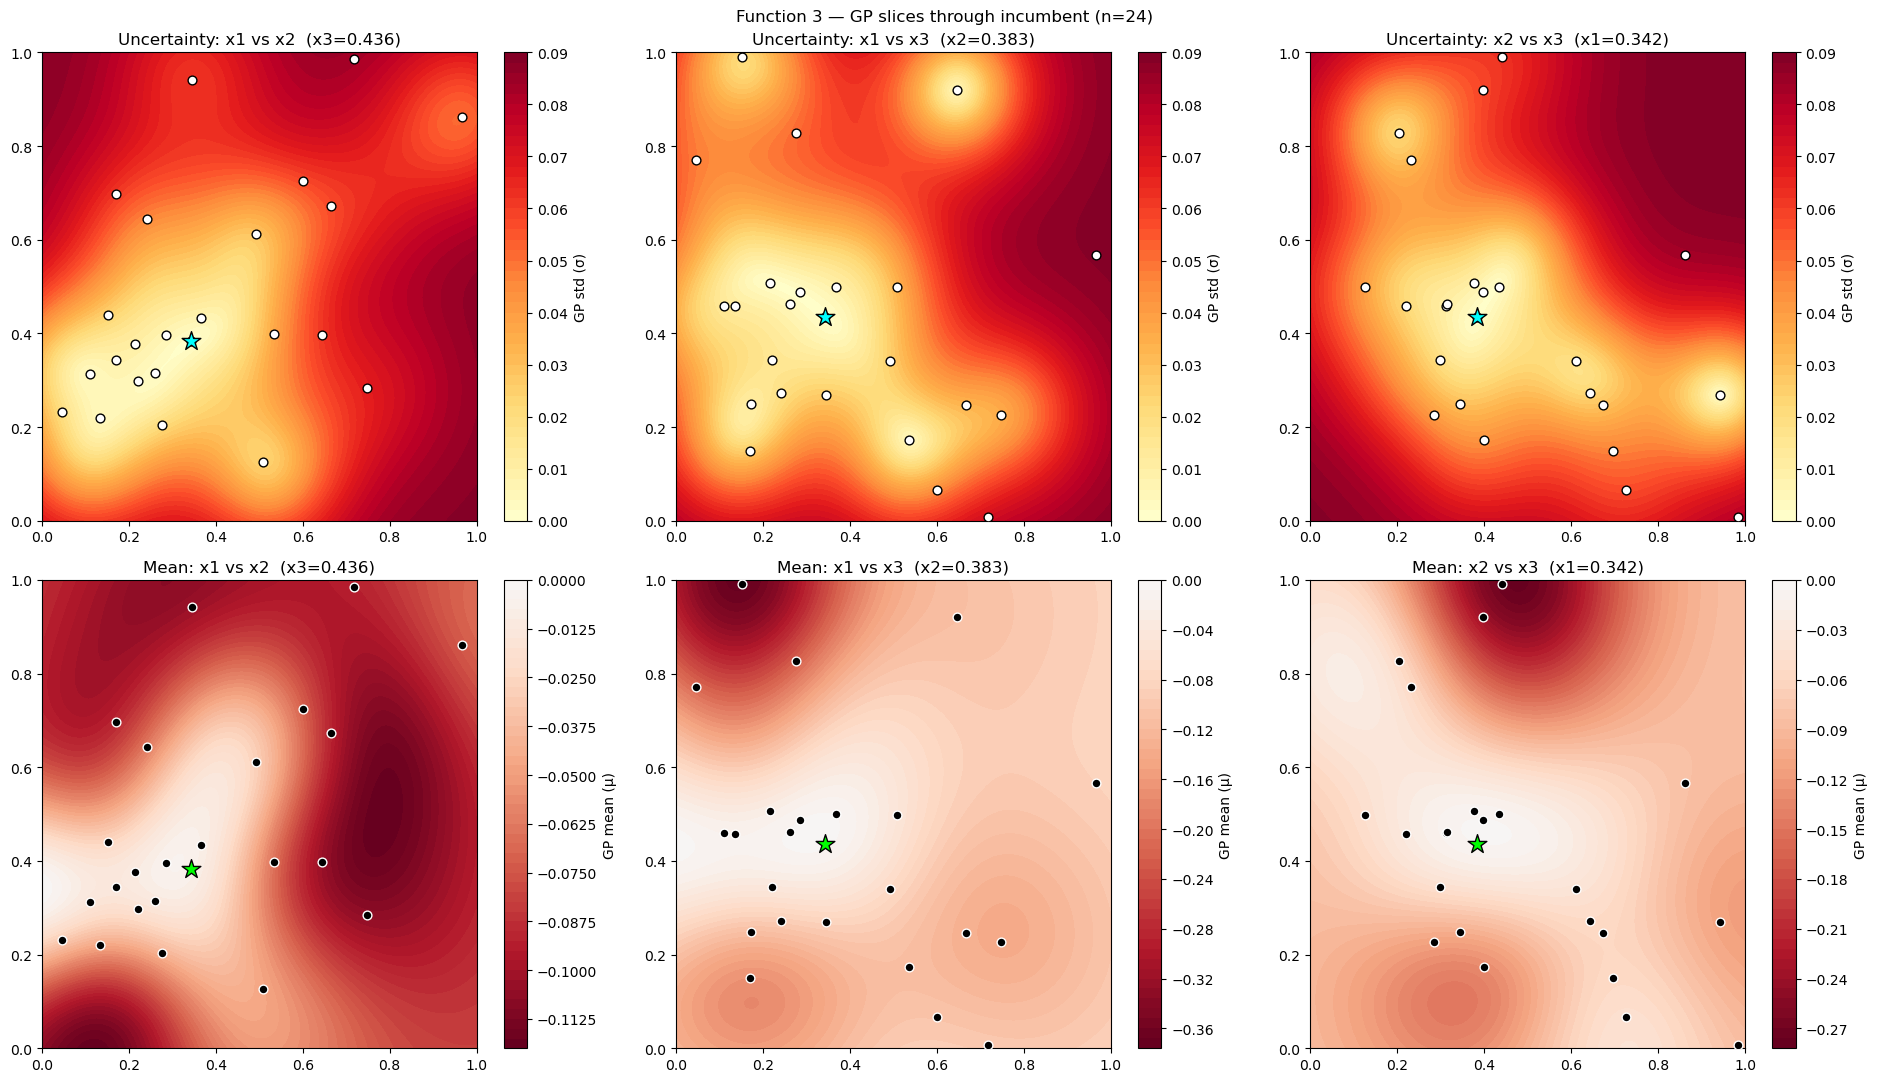

In [14]:
n_grid = 150
lin = np.linspace(0, 1, n_grid)
x_best = X[np.argmax(y)]   # <-- add this line

slices = [(0, 1, 2, 'x1', 'x2', 'x3'), (0, 2, 1, 'x1', 'x3', 'x2'), (1, 2, 0, 'x2', 'x3', 'x1')]

fig, axes = plt.subplots(2, 3, figsize=(19, 11))

for col, (i, j, held, xi, xj, xheld) in enumerate(slices):
    Ai, Aj = np.meshgrid(lin, lin)
    grid = np.zeros((n_grid * n_grid, 3))
    grid[:, i] = Ai.ravel()
    grid[:, j] = Aj.ravel()
    grid[:, held] = x_best[held]

    mu, sigma = gpr.predict(grid, return_std=True)
    mu_g, sigma_g = mu.reshape(n_grid, n_grid), sigma.reshape(n_grid, n_grid)

    ax = axes[0, col]
    im = ax.contourf(Ai, Aj, sigma_g, levels=50, cmap='YlOrRd')
    ax.scatter(X[:, i], X[:, j], c='white', edgecolors='black', s=40, zorder=5)
    ax.scatter([x_best[i]], [x_best[j]], marker='*', c='cyan', s=200, edgecolors='k', zorder=6)
    plt.colorbar(im, ax=ax, label='GP std (σ)')
    ax.set_title(f'Uncertainty: {xi} vs {xj}  ({xheld}={x_best[held]:.3f})')

    ax2 = axes[1, col]
    im2 = ax2.contourf(Ai, Aj, mu_g, levels=50, cmap='RdBu', vmin=-abs(mu_g).max(), vmax=abs(mu_g).max())
    ax2.scatter(X[:, i], X[:, j], c='black', edgecolors='white', s=40, zorder=5)
    ax2.scatter([x_best[i]], [x_best[j]], marker='*', c='lime', s=200, edgecolors='k', zorder=6)
    plt.colorbar(im2, ax=ax2, label='GP mean (μ)')
    ax2.set_title(f'Mean: {xi} vs {xj}  ({xheld}={x_best[held]:.3f})')

fig.suptitle('Function 3 — GP slices through incumbent (n=24)')
plt.tight_layout()
plt.show()
